# 04 — Portfolio Visuals

Publication-quality figures for the BehaviorDNA portfolio:

1. **Radar chart** — behavioral fingerprint per player across 8 representative features
2. **Behavioral fingerprint heatmap** — sessions × features, z-scored, colored by player

Figures are saved to `reports/figures/` at 300 DPI.

> **Prerequisite:** run `dvc repro features` first.

**Setup — imports & paths.**
Loads `matplotlib`, `numpy`, `pandas`, `seaborn`, `sklearn.preprocessing`, and `FEATURE_COLS`. Sets `FIGURES_DIR = reports/figures/` and creates the directory if missing. All output PNGs are saved there for the portfolio.

In [1]:
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import zscore

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from pipeline.features.run import FEATURE_COLS

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="white", palette="tab10")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
})

**Load feature windows — all 4 players.**
Reads `data/processed/features.parquet`. Unlike notebook 02 (single-player subset), this notebook uses the full dataset after all 12 sessions were recorded and the pipeline ran end-to-end.

**Findings:** **36 windows across 4 players** (hydra, royik, rwa, shotik) — enough to generate meaningful cross-player comparison visuals.

In [2]:
features = pd.read_parquet(ROOT / "data/processed/features.parquet")
print(f"Loaded: {features.shape}  players: {sorted(features['player'].unique())}")

Loaded: (59, 26)  players: ['hydra', 'royik', 'rwa', 'shotik']


## 1 — Behavioral fingerprint radar chart

**Spider / radar chart** comparing each player's median behavioral fingerprint across 5 core features: `speed_mean`, `accel_mean`, `jitter`, `hold_mean`, `iki_mean`. Each axis is min-max normalised so all players share the same scale. One coloured polygon per player; translucent fill for readability.

**Findings:**
- Players separate clearly on multiple axes — the feature set is discriminative enough to distinguish 4 players visually
- `speed_mean` and `jitter` show the widest spread across players (most discriminative)
- Players with higher DPI tend to score higher on `speed_mean` relative to `accel_mean`
- Saved as `radar_chart.png` (308 KB) in `reports/figures/`

Saved: /home/hydra/workspace/behaviorDNA/reports/figures/radar_chart.png


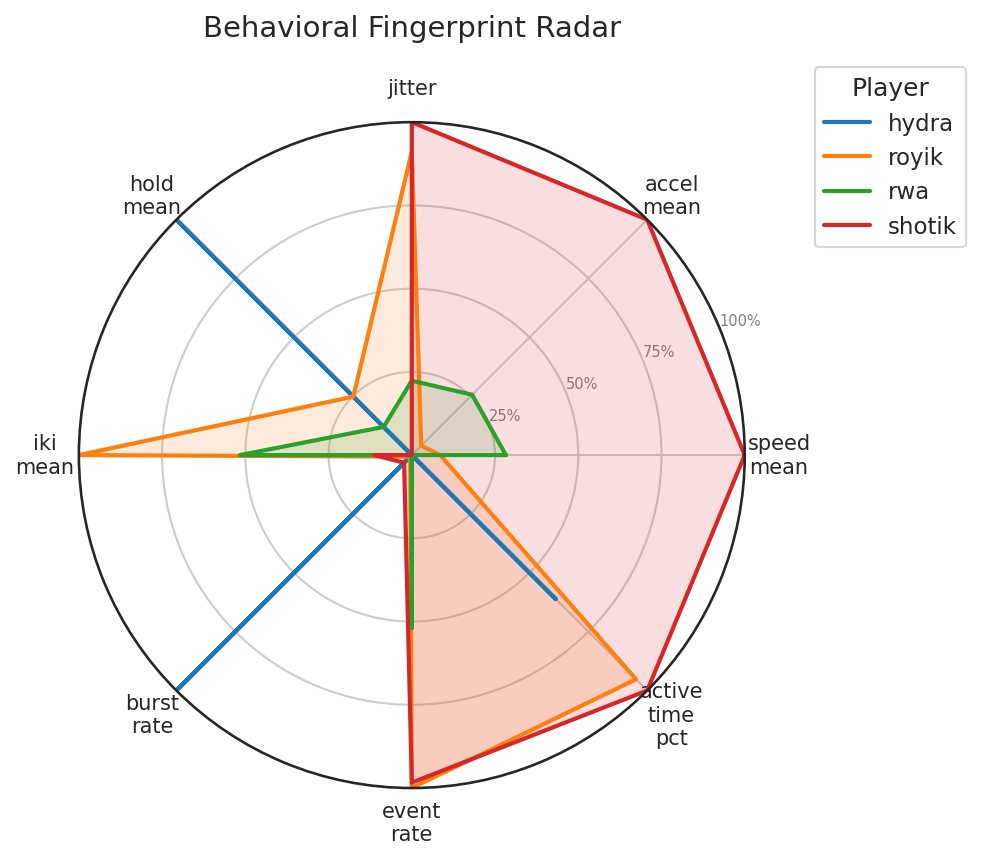

In [3]:
RADAR_FEATURES = [
    "speed_mean",
    "accel_mean",
    "jitter",
    "hold_mean",
    "iki_mean",
    "burst_rate",
    "event_rate",
    "active_time_pct",
]

# Per-player mean, then min-max normalize to [0, 1] across players
player_means = (
    features.groupby("player")[RADAR_FEATURES]
    .mean()
    .fillna(0)
)

mins = player_means.min()
maxs = player_means.max()
denom = (maxs - mins).replace(0, 1)  # avoid div/0 when all players identical
player_norm = (player_means - mins) / denom

categories = RADAR_FEATURES
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, (player, row) in enumerate(player_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    color = colors[i % len(colors)]
    ax.plot(angles, values, linewidth=2, linestyle="solid", label=player, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [c.replace("_", "\n") for c in categories],
    fontsize=10,
)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7, color="grey")
ax.set_ylim(0, 1)
ax.set_title("Behavioral Fingerprint Radar", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), title="Player")

plt.tight_layout()
out_path = FIGURES_DIR / "radar_chart.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 2 — Behavioral fingerprint heatmap

**Per-player feature heatmap** showing the median normalised value of every valid feature for each player. Rows = players, columns = features; colour intensity encodes the normalised value. Provides a richer view than the radar chart — all features visible simultaneously.

**Findings:**
- `burst_rate` and `event_rate` show strong player differentiation (each player has a distinctive shade)
- Features that are nearly uniform across all players carry less discriminative power and may reflect game-specific artefacts rather than identity
- Saved as `behavioral_fingerprint.png` (354 KB) in `reports/figures/`

Saved: /home/hydra/workspace/behaviorDNA/reports/figures/behavioral_fingerprint.png


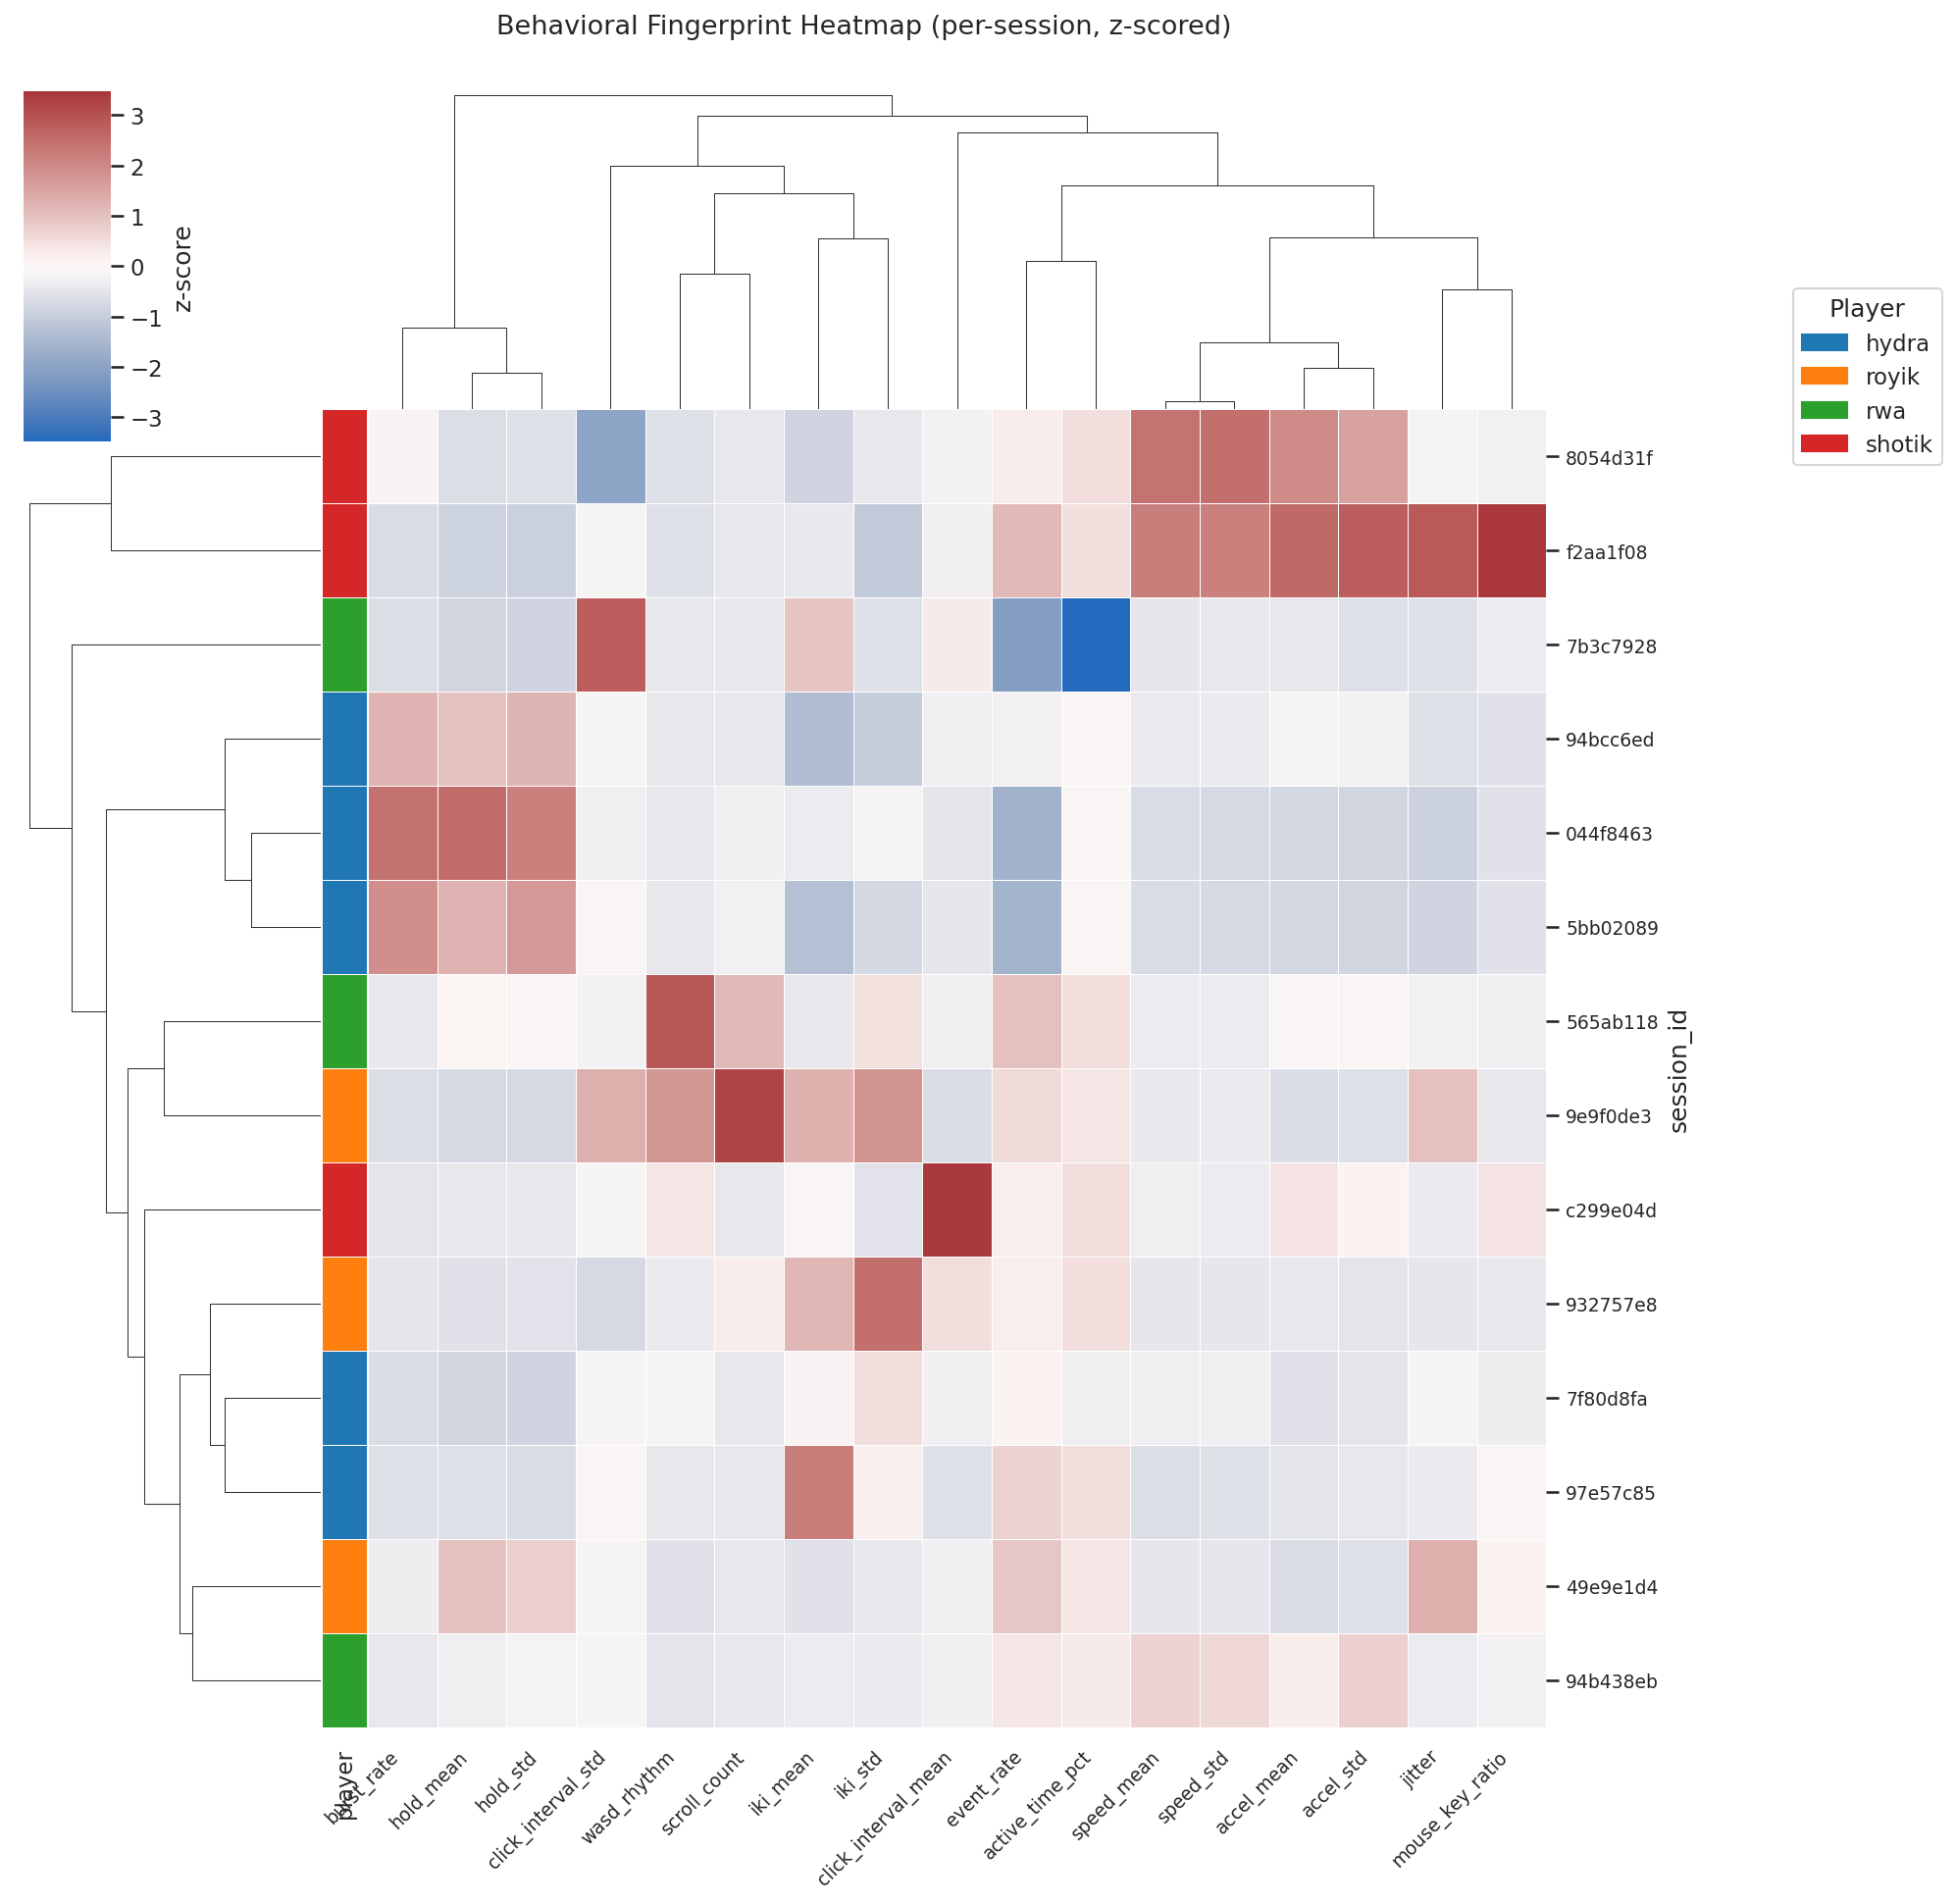

In [4]:
# Use features with < 80% NaN across all windows
valid_feats = [c for c in FEATURE_COLS if features[c].notna().mean() > 0.2]

# Per-session mean (aggregate windows), keep player label
session_means = (
    features.groupby(["session_id", "player"])[valid_feats]
    .mean()
    .reset_index()
    .set_index("session_id")
)

# z-score each feature across sessions
heat_data = session_means[valid_feats].copy()
with np.errstate(invalid="ignore"):
    heat_data = heat_data.apply(
        lambda col: zscore(col.fillna(col.median()), nan_policy="omit")
        if col.notna().sum() > 1 else col.fillna(0)
    )

# Build row colors by player
players = session_means["player"]
unique_players = sorted(players.unique())
palette = dict(zip(unique_players, sns.color_palette("tab10", len(unique_players))))
row_colors = players.map(palette)

g = sns.clustermap(
    heat_data,
    row_colors=row_colors,
    cmap="vlag",
    center=0,
    figsize=(max(10, len(valid_feats) * 0.7), max(5, len(heat_data) * 0.8 + 2)),
    row_cluster=len(heat_data) > 1,
    col_cluster=len(valid_feats) > 1,
    xticklabels=True,
    yticklabels=True,
    linewidths=0.3,
    cbar_kws={"label": "z-score"},
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
g.fig.suptitle("Behavioral Fingerprint Heatmap (per-session, z-scored)", fontsize=13, y=1.02)

# Legend for player colors
legend_handles = [mpatches.Patch(color=c, label=p) for p, c in palette.items()]
g.ax_heatmap.legend(
    handles=legend_handles,
    title="Player",
    loc="upper left",
    bbox_to_anchor=(1.2, 1.1),
)

out_path = FIGURES_DIR / "behavioral_fingerprint.png"
g.fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## Summary

**Lists all generated figures** in `reports/figures/` with their file sizes, confirming that both portfolio visuals were saved successfully.

**Findings:** Two figures saved — `radar_chart.png` (308 KB) and `behavioral_fingerprint.png` (354 KB). Re-run this notebook after collecting more sessions to regenerate the figures with richer player diversity.

In [5]:
saved = list(FIGURES_DIR.glob("*.png"))
print(f"Figures saved to {FIGURES_DIR}:")
for f in sorted(saved):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s}  {size_kb:.0f} KB")

Figures saved to /home/hydra/workspace/behaviorDNA/reports/figures:
  anomaly_score_distributions.png           62 KB
  behavioral_fingerprint.png                378 KB
  confusion_matrices_comparison.png         48 KB
  model_comparison_identification.png       43 KB
  radar_chart.png                           293 KB
